In [81]:
# Import required libraries
%reset -f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.ticker as ticker
import os

In [82]:
# Configuration
file2 = 'S_Pos03_Re100_B0001_T.csv'
folder_name1 = '../40/sim/40'  # Simulation folder
folder_name2 = '../40/exp/40'  # Experimental folder

#exp_folder = '../irregular/exp/Pos3_transformed'
#sim_folder = '../irregular/sim/irregular_0.07_extended/Pos3_transformed'

folder_name = '40_Re_100'  # Output folder for plots
output_dir = '../Plots/'+ folder_name

n_arrows = 14
# Add constant offsets to velocity components (set to 0 for no offset)
z_velocity_offset = 0.0   # Constant term to add to Z-velocity [m/s]    #3 = 0.05;40_1:015, 40_3:0, Ire_1:0.02 ir_3:0.1

In [83]:
# Automatically extract position number from filename
import re
pos_match = re.search(r'Pos(\d+)', file2)
if pos_match:
    pos = int(pos_match.group(1))
    print(f"Automatically detected Position: {pos}")
else:
    pos = 1  # Default fallback
    print(f"Could not detect position from filename, using default: {pos}")


# File paths
file2_path = folder_name2 + '/' + file2 # Experimental filename
file1 = 'SIM_' + file2  # Simulation filename
file1_path = folder_name1 + '/' + file1

# Plot settings

file_type='aver'
#file_type='inst'

axis_1 = 'Points_0'
axis_2 = 'Points_2'

plot_type = 'horizontal'
#plot_type = 'vertical'

label1 = "simulation"
label2 = "experiment"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Automatically detected Position: 3


In [84]:
# Define both normalization functions
def normalize_x_axis(df):
    """Normalize Points_0 (x-axis) to range [0,1]"""
    df = df.copy()
    x_min = df['Points_0'].min()
    x_max = df['Points_0'].max()
    df['Points_0_normalized'] = (df['Points_0'] - x_min) / (x_max - x_min)
    return df
def normalize_y_axis(df):
    """Normalize Points_1 (y-axis) to range [0,1]"""
    df = df.copy()
    y_min = df['Points_1'].min()
    y_max = df['Points_1'].max()
    df['Points_1_normalized'] = (df['Points_1'] - y_min) / (y_max - y_min)
    return df
# Create function to do both normalizations in one step
def normalize_xy(df):
    """Normalize both x and y axes to range [0,1]"""
    df = df.copy()
    
    # Normalize x-axis
    x_min = df['Points_0'].min()
    x_max = df['Points_0'].max()
    df['Points_0_normalized'] = (df['Points_0'] - x_min) / (x_max - x_min)
    
    # Normalize y-axis
    y_min = df['Points_1'].min()
    y_max = df['Points_1'].max()
    df['Points_1_normalized'] = (df['Points_1'] - y_min) / (y_max - y_min)
    
    return df

if file_type=='inst':
    var = 'Velocity_2'
    vx = 'Velocity_0'
    vy = 'Velocity_1'
    vz = 'Velocity_2'
else:
    var = 'av_u_2'
    vx = 'av_u_0'
    vy = 'av_u_1'
    vz = 'av_u_2'
    
# Load CSV files
df1 = pd.read_csv(file1_path)  # Simulation data
df2 = pd.read_csv(file2_path)  # Experimental data

df1['av_u_2'] = df1['av_u_2'] + z_velocity_offset
print(f"Loaded {label1}: {df1.shape[0]} points")
print(f"Loaded {label2}: {df2.shape[0]} points")

# Map experimental column names to simulation format
header_mapping = {
    'x': 'Points_0',
    'x ': 'Points_0',
    'y': 'Points_1',
    'y ': 'Points_1',
    'z': 'Points_2',
    'z ': 'Points_2',
    'Vel_u': 'av_u_0',
    'Vel_v': 'av_u_1',
    'Vel_w': 'av_u_2',
    'Vel_mag': 'av_u_Magnitude'
}

df2 = df2.rename(columns=header_mapping)
print("Column mapping complete")
# Define axis columns (both datasets now use same format)
axis_1_df1 = 'Points_0'  # X coordinate
axis_2_df1 = 'Points_2'  # Z coordinate
axis_1_df2 = 'Points_0'
axis_2_df2 = 'Points_2'

# Define velocity columns
vx_df1 = 'av_u_0' 
vz_df1 = 'av_u_2'
vx_df2 = 'av_u_0'
vz_df2 = 'av_u_2' 
var = 'av_u_2'  # Z velocity component for colorbar

# Filter simulation data to match experimental bounds
decimals = 6
axis_1_min = round(df2[axis_1_df2].min(), decimals)
axis_1_max = round(df2[axis_1_df2].max(), decimals)
axis_2_min = round(df2[axis_2_df2].min(), decimals)
axis_2_max = round(df2[axis_2_df2].max(), decimals)

df1 = df1[
    (df1[axis_1_df1].round(decimals) >= axis_1_min) & 
    (df1[axis_1_df1].round(decimals) <= axis_1_max) &
    (df1[axis_2_df1].round(decimals) >= axis_2_min) &
    (df1[axis_2_df1].round(decimals) <= axis_2_max)
]

print(f"Filtered {label1}: {df1.shape[0]} points")

Loaded simulation: 46550 points
Loaded experiment: 38250 points
Column mapping complete
Filtered simulation: 38646 points


In [85]:
# Calculate velocity magnitude
df1_normalized = df1.copy()
df1_normalized["vel_cal"] = np.sqrt(df1_normalized['av_u_0']**2 + df1_normalized['av_u_2']**2)
df2["vel_cal"] = np.sqrt(df2['av_u_0']**2 + df2['av_u_2']**2)

# Create maximum velocity comparison table
print("=" * 80)
print("MAXIMUM VELOCITY COMPARISON")
print("=" * 80)

# Create DataFrame for table
velocity_comparison = pd.DataFrame({
    'Component': ['X-velocity (av_u_0)', 'Z-velocity (av_u_2)', 'Total magnitude (vel_cal)'],
    'Experiment [m/s]': [
        df2['av_u_0'].max(),
        df2['av_u_2'].max(),
        df2['vel_cal'].max()
    ],
    'Simulation [m/s]': [
        df1_normalized['av_u_0'].max(),
        df1_normalized['av_u_2'].max(),
        df1_normalized['vel_cal'].max()
    ]
})

# Calculate differences and percentage
velocity_comparison['Difference [m/s]'] = (
    velocity_comparison['Simulation [m/s]'] - velocity_comparison['Experiment [m/s]']
)
velocity_comparison['Relative Diff [%]'] = (
    (velocity_comparison['Difference [m/s]'] / velocity_comparison['Experiment [m/s]']) * 100
)

# Format the numbers
pd.options.display.float_format = '{:.6f}'.format

print("\n" + velocity_comparison.to_string(index=False))
print("\n" + "=" * 80 + "\n")

# Reset display format
pd.reset_option('display.float_format')

MAXIMUM VELOCITY COMPARISON

                Component  Experiment [m/s]  Simulation [m/s]  Difference [m/s]  Relative Diff [%]
      X-velocity (av_u_0)          0.103831          0.086503         -0.017328         -16.688522
      Z-velocity (av_u_2)          0.580412          0.556163         -0.024249          -4.177927
Total magnitude (vel_cal)          0.584004          0.559135         -0.024869          -4.258365




In [86]:
# Determine common bounds automatically from experimental data
x_min_exp = df2[axis_1_df2].min()
x_max_exp = df2[axis_1_df2].max()
z_min_exp = df2[axis_2_df2].min()
z_max_exp = df2[axis_2_df2].max()

# Check simulation data coverage
x_min_sim = df1_normalized[axis_1_df1].min()
x_max_sim = df1_normalized[axis_1_df1].max()
z_min_sim = df1_normalized[axis_2_df1].min()
z_max_sim = df1_normalized[axis_2_df1].max()

print("DOMAIN VALIDATION CHECK")
print(f"{label2.upper()} domain:")
print(f"  X: [{x_min_exp:.6f}, {x_max_exp:.6f}] m")
print(f"  Z: [{z_min_exp:.6f}, {z_max_exp:.6f}] m")
print(f"{label1.upper()} domain:")
print(f"  X: [{x_min_sim:.6f}, {x_max_sim:.6f}] m")
print(f"  Z: [{z_min_sim:.6f}, {z_max_sim:.6f}] m")

# Calculate OVERLAPPING region (intersection of both domains)
x_min_common = max(x_min_exp, x_min_sim)
x_max_common = min(x_max_exp, x_max_sim)
z_min_common = max(z_min_exp, z_min_sim)
z_max_common = min(z_max_exp, z_max_sim)

# Use overlapping region as common bounds
common_bounds = (x_min_common, x_max_common, z_min_common, z_max_common)
print("Common overlapping domain:")
print(f"  X: [{common_bounds[0]:.6f}, {common_bounds[1]:.6f}] m")
print(f"  Z: [{common_bounds[2]:.6f}, {common_bounds[3]:.6f}] m")

# Filter both datasets to the common overlapping region
df1_consistent = df1_normalized[
    (df1_normalized[axis_1_df1] >= common_bounds[0]) & 
    (df1_normalized[axis_1_df1] <= common_bounds[1]) &
    (df1_normalized[axis_2_df1] >= common_bounds[2]) &
    (df1_normalized[axis_2_df1] <= common_bounds[3])
].copy()

df2_consistent = df2[
    (df2[axis_1_df2] >= common_bounds[0]) & 
    (df2[axis_1_df2] <= common_bounds[1]) &
    (df2[axis_2_df2] >= common_bounds[2]) &
    (df2[axis_2_df2] <= common_bounds[3])
].copy()

DOMAIN VALIDATION CHECK
EXPERIMENT domain:
  X: [-0.033915, 0.034034] m
  Z: [0.181730, 0.232995] m
SIMULATION domain:
  X: [-0.033750, 0.033750] m
  Z: [0.181750, 0.232750] m
Common overlapping domain:
  X: [-0.033750, 0.033750] m
  Z: [0.181750, 0.232750] m


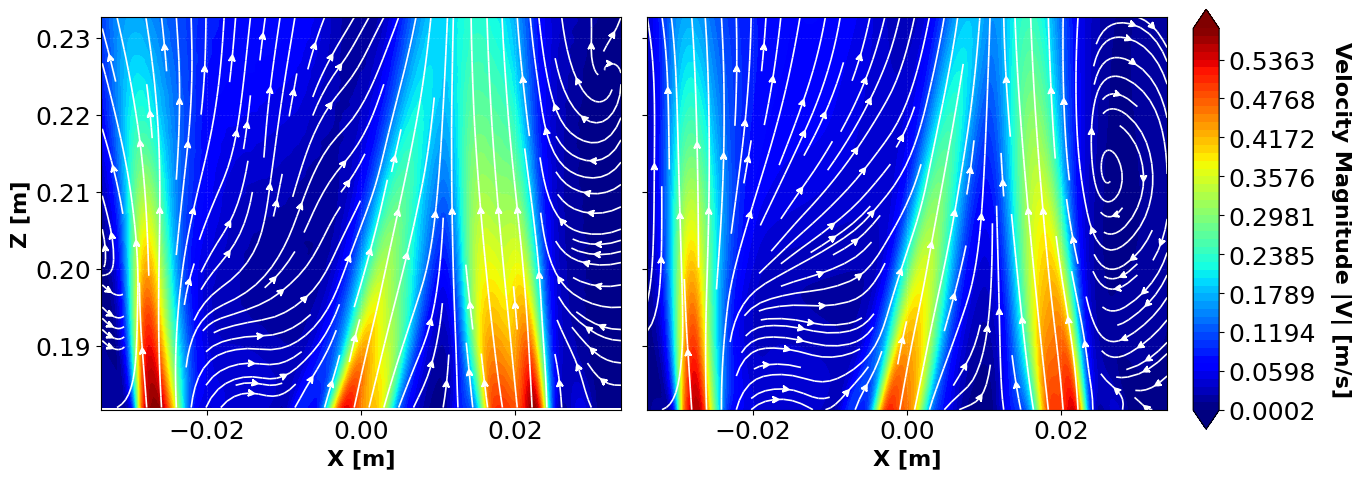

In [87]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Use consistent data (common overlapping region)
# Calculate color range from velocity magnitude
df1_mag_min = df1_consistent['vel_cal'].min()
df1_mag_max = df1_consistent['vel_cal'].max()
df2_mag_min = df2_consistent['vel_cal'].min()
df2_mag_max = df2_consistent['vel_cal'].max()

# Use combined range for consistent color scale
common_vmin = min(df1_mag_min, df2_mag_min)
common_vmax = max(df1_mag_max, df2_mag_max)

if common_vmax <= common_vmin:
    common_vmax = common_vmin + 0.001

levels = np.linspace(common_vmin, common_vmax, 50)

# Clean data - remove NaN and inf values
df2_clean = df2_consistent.dropna(subset=[axis_1_df2, axis_2_df2, vx_df2, vz_df2, 'vel_cal']).copy()
df1_clean = df1_consistent.dropna(subset=[axis_1_df1, axis_2_df1, vx_df1, vz_df1, 'vel_cal']).copy()
df2_clean = df2_clean[np.isfinite(df2_clean['vel_cal'])]
df1_clean = df1_clean[np.isfinite(df1_clean['vel_cal'])]

# Apply offsets to both datasets
df2_clean[vx_df2] = df2_clean[vx_df2]
df2_clean[vz_df2] = df2_clean[vz_df2]
df1_clean[vx_df1] = df1_clean[vx_df1]
df1_clean[vz_df1] = df1_clean[vz_df1] 

# Recalculate velocity magnitude with offsets
df2_clean['vel_cal'] = np.sqrt(df2_clean[vx_df2]**2 + df2_clean[vz_df2]**2)
df1_clean['vel_cal'] = np.sqrt(df1_clean[vx_df1]**2 + df1_clean[vz_df1]**2)

# Recalculate color range after applying offsets
df1_mag_min = df1_clean['vel_cal'].min()
df1_mag_max = df1_clean['vel_cal'].max()
df2_mag_min = df2_clean['vel_cal'].min()
df2_mag_max = df2_clean['vel_cal'].max()
common_vmin = min(df1_mag_min, df2_mag_min)
common_vmax = max(df1_mag_max, df2_mag_max)
levels = np.linspace(common_vmin, common_vmax, 50)

# Process experimental data for streamlines (X-Z only)
points2 = np.column_stack((df2_clean[axis_1_df2], df2_clean[axis_2_df2]))
x2_points = np.linspace(df2_clean[axis_1_df2].min(), df2_clean[axis_1_df2].max(), n_arrows)
z2_points = np.linspace(df2_clean[axis_2_df2].min(), df2_clean[axis_2_df2].max(), n_arrows)
X2, Z2 = np.meshgrid(x2_points, z2_points)

U2 = griddata(points2, df2_clean[vx_df2].values, (X2, Z2), method='linear', fill_value=0)
V2 = griddata(points2, df2_clean[vz_df2].values, (X2, Z2), method='linear', fill_value=0)

# Normalize streamline directions (for visualization only, not data)
magnitude2 = np.sqrt(U2**2 + V2**2)
mask2 = magnitude2 > 0.0001
U2_norm = np.zeros_like(U2)
V2_norm = np.zeros_like(V2)
U2_norm[mask2] = U2[mask2] / magnitude2[mask2]
V2_norm[mask2] = V2[mask2] / magnitude2[mask2]

# Process simulation data for streamlines (X-Z only)
points1 = np.column_stack((df1_clean[axis_1_df1], df1_clean[axis_2_df1]))
x1_points = np.linspace(df1_clean[axis_1_df1].min(), df1_clean[axis_1_df1].max(), n_arrows)
z1_points = np.linspace(df1_clean[axis_2_df1].min(), df1_clean[axis_2_df1].max(), n_arrows)
X1, Z1 = np.meshgrid(x1_points, z1_points)

U1 = griddata(points1, df1_clean[vx_df1].values, (X1, Z1), method='linear', fill_value=0)
V1 = griddata(points1, df1_clean[vz_df1].values - z_velocity_offset, (X1, Z1), method='linear', fill_value=0)

# Normalize streamline directions (for visualization only, not data)
magnitude1 = np.sqrt(U1**2 + V1**2)
mask1 = magnitude1 > 0.0001
U1_norm = np.zeros_like(U1)
V1_norm = np.zeros_like(V1)
U1_norm[mask1] = U1[mask1] / magnitude1[mask1]
V1_norm[mask1] = V1[mask1] / magnitude1[mask1]

# Create contour plots with velocity magnitude
#1 = EXPERIMENT
#2 = SIMULATION
contour1 = ax1.tricontourf(df2_clean[axis_1_df2].values, df2_clean[axis_2_df2].values, 
                           df2_clean['vel_cal'].values,  # Velocity magnitude
                           levels=levels, cmap='jet', vmin=common_vmin, vmax=common_vmax, extend='both')
ax1.streamplot(X2, Z2, U2_norm, V2_norm, density=1.2, color='white', 
               linewidth=1.2, arrowsize=1.0, arrowstyle='fancy')

contour2 = ax2.tricontourf(df1_clean[axis_1_df1].values, df1_clean[axis_2_df1].values, 
                           df1_clean['vel_cal'].values,  # Velocity magnitude
                           levels=levels, cmap='jet', vmin=common_vmin, vmax=common_vmax, extend='both')
ax2.streamplot(X1, Z1, U1_norm, V1_norm, density=1.2, color='white', 
               linewidth=1.2, arrowsize=1.0, arrowstyle='fancy')

# Configure axes
ax1.set_xlabel('X [m]', fontsize=16, fontweight='bold')
ax1.set_ylabel('Z [m]', fontsize=16, fontweight='bold')
ax2.set_xlabel('X [m]', fontsize=16, fontweight='bold')


for ax in [ax1, ax2]:
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    ax.tick_params(axis='x', which='both', labelsize=18)
    ax.tick_params(axis='y', which='both', labelsize=18)
    ax.set_xlim(common_bounds[0], common_bounds[1])
    ax.set_ylim(common_bounds[2], common_bounds[3])

ax2.tick_params(axis='y', which='major', labelleft=False)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(contour1, cax=cbar_ax)
cbar.set_label('Velocity Magnitude |V| [m/s]', rotation=270, labelpad=25, fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=18)

# Adjust layout
plt.subplots_adjust(left=0.08, right=0.90, top=0.90, bottom=0.12, wspace=0.05)

# Save figure
plt.savefig(f'{output_dir}/pos{pos}_Surface_plot.png',dpi=300, bbox_inches='tight')
plt.show()

In [88]:
# Line plots at specific Z-heights (adaptive based on common domain)
z_min_common = 0.183 #common_bounds[2]
z_max_common = 0.220 #common_bounds[3]       #Hardcoded
z_step = 0.01

z_values = np.arange(z_min_common, z_max_common + 1e-12, z_step)

print(f"Generating line plots from Z = {z_min_common*1000:.3f} mm to {z_max_common*1000:.3f} mm")
print(f"Step size: {z_step*1000:.3f} mm")
print("Z values (mm):", [f"{z*1000:.2f}" for z in z_values])
print(f"Total number of plots: {len(z_values)}")


Generating line plots from Z = 183.000 mm to 220.000 mm
Step size: 10.000 mm
Z values (mm): ['183.00', '193.00', '203.00', '213.00']
Total number of plots: 4


Generating line plots at specified Z values (mm): [183. 193. 203. 213.]
Total number of plots: 4
Target Z = 183.0 mm: simulation Z = 182.950 mm, experiment Z = 182.944 mm
Target Z = 193.0 mm: simulation Z = 192.850 mm, experiment Z = 192.954 mm
Target Z = 203.0 mm: simulation Z = 203.050 mm, experiment Z = 202.964 mm
Target Z = 213.0 mm: simulation Z = 212.950 mm, experiment Z = 212.975 mm


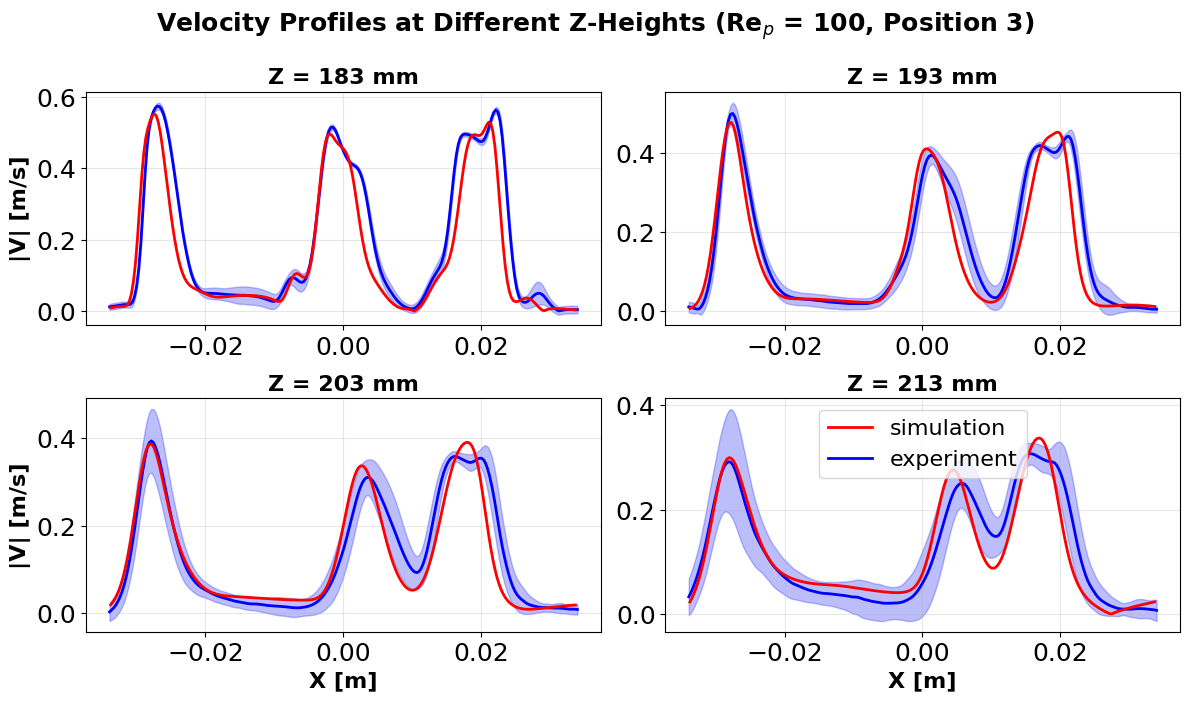

In [89]:
z_values_mm = z_values * 1000  # Convert to mm

# Convert to meters
z_values_m = [z / 1000.0 for z in z_values_mm]

print(f"Generating line plots at specified Z values (mm): {z_values_mm}")
print(f"Total number of plots: {len(z_values_m)}")

z_results = []
z_w_max_sim = []
z_w_max_exp = []
stored_data = []

for z_target in z_values_m:
    deci = 5
    
    # Find closest z-value in each dataset
    closest_y_df1 = df1[axis_2_df1].iloc[(df1[axis_2_df1] - z_target).abs().argsort()[:1]].iloc[0]
    closest_y_df2 = df2[axis_2_df2].iloc[(df2[axis_2_df2] - z_target).abs().argsort()[:1]].iloc[0]
    
    # Print the Z value for each dataset where the plot is being generated
    print(f"Target Z = {z_target*1000:.1f} mm: {label1} Z = {closest_y_df1*1000:.3f} mm, {label2} Z = {closest_y_df2*1000:.3f} mm")
    
    # Filter the data for these closest y values with small tolerance
    df1_filtered = df1[abs(df1[axis_2_df1] - closest_y_df1) < 10**(-deci)]
    df2_filtered = df2[abs(df2[axis_2_df2] - closest_y_df2) < 10**(-deci)]
    
    # Sort the filtered data by the x-axis for proper plotting
    df1_filtered = df1_filtered.sort_values(axis_1_df1)
    df2_filtered = df2_filtered.sort_values(axis_1_df2)
    
    # Calculate velocity magnitude
    magnitude_df1 = np.sqrt(df1_filtered['av_u_0']**2 + df1_filtered['av_u_2']**2)
    magnitude_df2 = np.sqrt(df2_filtered['av_u_0']**2 + df2_filtered['av_u_2']**2)
    
    # Get standard deviations from experimental data
    if 'Stand_dev_Vx' in df2_filtered.columns and 'Stand_dev_Vz' in df2_filtered.columns:
        std_u = df2_filtered['Stand_dev_Vx'].values
        std_w = df2_filtered['Stand_dev_Vz'].values
        
        # Calculate uncertainty in magnitude using error propagation
        u_vals = df2_filtered['av_u_0'].values
        w_vals = df2_filtered['av_u_2'].values
        
        # Avoid division by zero
        magnitude_vals = magnitude_df2.values
        magnitude_vals[magnitude_vals < 1e-10] = 1e-10
        
        std_magnitude = np.sqrt((u_vals * std_u)**2 + (w_vals * std_w)**2) / magnitude_vals
        has_std = True
    else:
        std_magnitude = np.zeros_like(magnitude_df2)
        has_std = False
    
    # Get maximum values
    w_max_sim = magnitude_df1.max() if len(magnitude_df1) > 0 else 0.0
    w_max_exp = magnitude_df2.max() if len(magnitude_df2) > 0 else 0.0
    
    # Store results
    z_results.append(z_target * 1000)
    z_w_max_sim.append(w_max_sim)
    z_w_max_exp.append(w_max_exp)
    
    # Store data for subplot
    stored_data.append({
        'z_target_mm': z_target * 1000,
        'z_sim': closest_y_df1 * 1000,
        'z_exp': closest_y_df2 * 1000,
        'x_sim': df1_filtered[axis_1_df1].values,
        'vel_sim': magnitude_df1.values,
        'x_exp': df2_filtered[axis_1_df2].values,
        'vel_exp': magnitude_df2.values,
        'std_exp': std_magnitude if has_std else None,
        'has_std': has_std
    })
# Create adaptive summary subplot
total_plots = len(stored_data)
if total_plots <= 4:
    n_rows, n_cols = 2, 2
    selected_indices = list(range(total_plots))
elif total_plots <= 9:
    n_rows, n_cols = 3, 3
    selected_indices = list(range(total_plots))
elif total_plots <= 16:
    n_rows, n_cols = 4, 4
    selected_indices = list(range(total_plots))
else:
    n_rows, n_cols = 5, 5
    step = max(1, total_plots // 25)
    selected_indices = list(range(0, total_plots, step))[:25]

# Ensure we have the right number of plots
n_subplots = n_rows * n_cols
selected_indices = selected_indices[:n_subplots]

#print(f"Creating summary subplot with {len(selected_indices)} plots ({n_rows}x{n_cols} grid)")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 3.5*n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

for i, idx in enumerate(selected_indices):
    data = stored_data[idx]
    ax = axes[i]
    
    # Plot simulation
    ax.plot(data['x_sim'], data['vel_sim'], label=label1, color='r', linestyle='-', linewidth=2, zorder=3)
    
    # Plot experiment with error bars if available
    if data['has_std'] and data['std_exp'] is not None:
        ax.fill_between(data['x_exp'],
                data['vel_exp'] - data['std_exp'],
                data['vel_exp'] + data['std_exp'],
                color="#1e28f2", alpha=0.3, zorder=1)
        ax.plot(data['x_exp'], data['vel_exp'], label=label2,
            color='b', linestyle='-', linewidth=2, zorder=2)
    else:
        ax.plot(data['x_exp'], data['vel_exp'], label=label2, color='b', 
               linestyle='--', linewidth=2, zorder=2)
    
    if i // n_cols == n_rows - 1:
        ax.set_xlabel('X [m]', fontsize=16, fontweight='bold')
    if i % n_cols == 0:
        ax.set_ylabel('|V| [m/s]', fontsize=16, fontweight='bold')
    ax.set_title(f'Z = {data["z_target_mm"]:.0f} mm', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=18)
ax.legend(fontsize=16)
# Hide unused subplots
for i in range(len(selected_indices), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Velocity Profiles at Different Z-Heights (Re$_p$ = 100, Position {pos})', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{output_dir}/Summary_Line_Profiles_Pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()


SUMMARY: Maximum Velocity Magnitude at Each Z-Slice
 Z_avg_mm   Z_sim_mm  Z_exp_mm  Max_Vel_Sim_m/s  Max_Vel_Exp_m/s  Difference_m/s  Rel_Diff_%
    183.0 182.950020   182.944         0.551764         0.573743       -0.021979   -3.830771
    193.0 192.849994   192.954         0.476405         0.499056       -0.022651   -4.538765
    203.0 203.050017   202.964         0.390805         0.394147       -0.003343   -0.848053
    213.0 212.949991   212.975         0.337115         0.306904        0.030211    9.843681

Average Difference (Sim - Exp) [m/s]: -0.004440
Average Absolute Difference [m/s]: 0.019546
Average Relative Difference [%]: 0.157


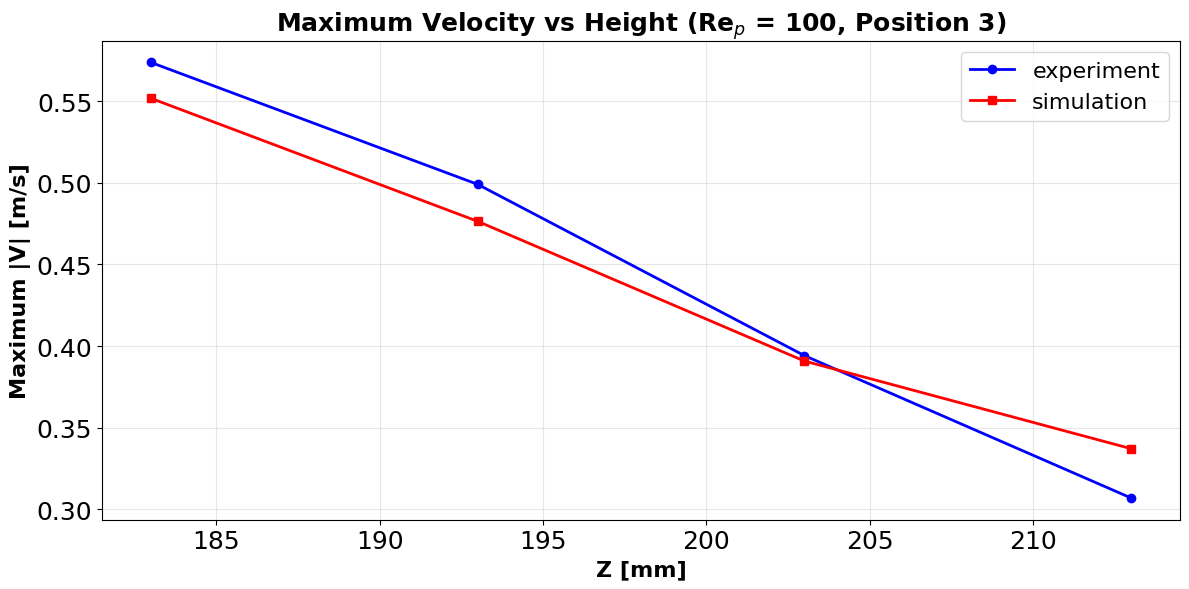

In [90]:
# Create summary DataFrame
summary_df = pd.DataFrame({
    'Z_avg_mm': z_results,
    'Z_sim_mm': [data['z_sim'] for data in stored_data],
    'Z_exp_mm': [data['z_exp'] for data in stored_data],
    'Max_Vel_Sim_m/s': z_w_max_sim,
    'Max_Vel_Exp_m/s': z_w_max_exp,
    'Difference_m/s': np.array(z_w_max_sim) - np.array(z_w_max_exp),
    'Rel_Diff_%': ((np.array(z_w_max_sim) - np.array(z_w_max_exp)) / np.array(z_w_max_exp)) * 100
})

print("\n" + "="*80)
print("SUMMARY: Maximum Velocity Magnitude at Each Z-Slice")
print("="*80)
print(summary_df.to_string(index=False))

# Average differences across all Z-slices
avg_diff = summary_df['Difference_m/s'].mean()
avg_abs_diff = summary_df['Difference_m/s'].abs().mean()
avg_rel_diff = summary_df['Rel_Diff_%'].mean()

print(f"\nAverage Difference (Sim - Exp) [m/s]: {avg_diff:.6f}")
print(f"Average Absolute Difference [m/s]: {avg_abs_diff:.6f}")
print(f"Average Relative Difference [%]: {avg_rel_diff:.3f}")

# Create plot showing max velocity variation with height
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(z_results, z_w_max_exp, 'bo-', label=label2, linewidth=2, markersize=6)
ax.plot(z_results, z_w_max_sim, 'rs-', label=label1, linewidth=2, markersize=6)
ax.set_xlabel('Z [mm]', fontsize=16, fontweight='bold')
ax.set_ylabel('Maximum |V| [m/s]', fontsize=16, fontweight='bold')
ax.set_title(f'Maximum Velocity vs Height (Re$_p$ = 100, Position {pos})', fontsize=18, fontweight='bold')
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=18)
plt.tight_layout()
plt.savefig(f'{output_dir}/Max_Velocity_vs_Height_Pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()

QUANTITATIVE VALIDATION METRICS  (n = 39006 grid points)
  R^2 (coeff. of determination) : 0.8771
  Pearson correlation r         : 0.9403
  RMSE                          : 0.0449 m/s
  NRMSE (vs exp range)          : 7.74 %
  NRMSE (vs exp mean)           : 32.86 %
  MAE                           : 0.0289 m/s
  Mean bias (sim - exp)         : -0.0108 m/s
  Linear fit  sim = 0.887*exp +0.005


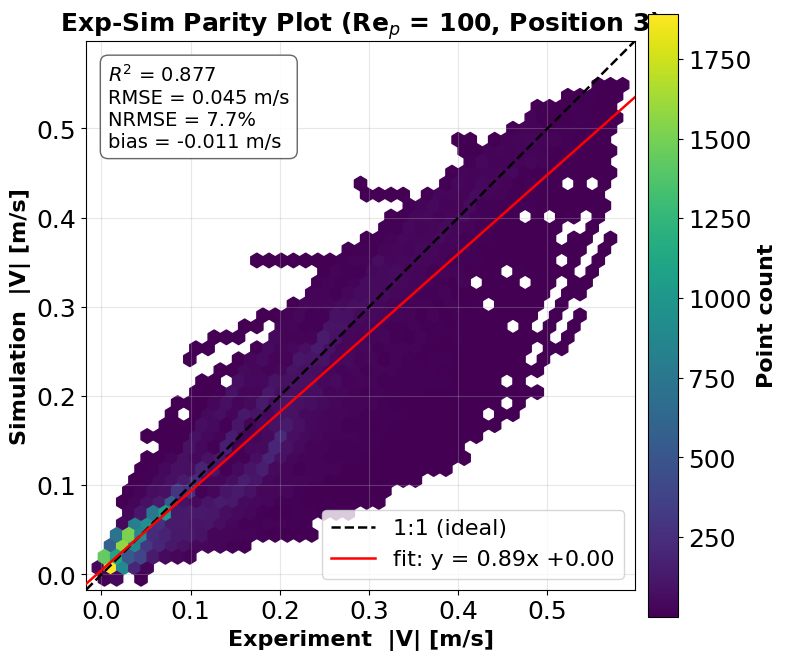

In [91]:
# =====================================================================
# QUANTITATIVE VALIDATION: Parity plot + statistical error metrics
# ---------------------------------------------------------------------
# Interpolates experiment and simulation onto a COMMON grid over the
# overlapping domain, then compares velocity magnitude point-by-point.
# Reports R^2, Pearson r, RMSE, NRMSE, MAE and mean bias - the standard
# metrics for exp-sim CFD validation in a publication.
# =====================================================================

# Clean source data (uses the same df1_clean / df2_clean built for the surface plot)
df_sim = df1_clean.dropna(subset=[axis_1_df1, axis_2_df1, 'vel_cal']).copy()
df_exp = df2_clean.dropna(subset=[axis_1_df2, axis_2_df2, 'vel_cal']).copy()

# Common regular grid over the overlapping domain
n_grid = 200
xg = np.linspace(common_bounds[0], common_bounds[1], n_grid)
zg = np.linspace(common_bounds[2], common_bounds[3], n_grid)
Xg, Zg = np.meshgrid(xg, zg)

# Interpolate both velocity-magnitude fields onto the common grid
sim_grid = griddata(np.column_stack((df_sim[axis_1_df1], df_sim[axis_2_df1])),
                    df_sim['vel_cal'].values, (Xg, Zg), method='linear')
exp_grid = griddata(np.column_stack((df_exp[axis_1_df2], df_exp[axis_2_df2])),
                    df_exp['vel_cal'].values, (Xg, Zg), method='linear')

# Keep only nodes where BOTH fields are defined
valid = np.isfinite(sim_grid) & np.isfinite(exp_grid)
e = exp_grid[valid]   # experiment = reference
s = sim_grid[valid]   # simulation

# ---- Statistical metrics ----
n_pts      = e.size
rmse       = np.sqrt(np.mean((s - e) ** 2))
mae        = np.mean(np.abs(s - e))
bias       = np.mean(s - e)                       # mean signed error (sim - exp)
nrmse_rng  = rmse / (e.max() - e.min()) * 100.0   # normalised by exp range [%]
nrmse_mean = rmse / e.mean() * 100.0              # normalised by exp mean  [%]
pearson_r  = np.corrcoef(e, s)[0, 1]
ss_res     = np.sum((s - e) ** 2)
ss_tot     = np.sum((e - e.mean()) ** 2)
r2         = 1.0 - ss_res / ss_tot                # coefficient of determination
# Least-squares linear fit  sim = a*exp + b
a_fit, b_fit = np.polyfit(e, s, 1)

print("=" * 70)
print(f"QUANTITATIVE VALIDATION METRICS  (n = {n_pts} grid points)")
print("=" * 70)
print(f"  R^2 (coeff. of determination) : {r2:.4f}")
print(f"  Pearson correlation r         : {pearson_r:.4f}")
print(f"  RMSE                          : {rmse:.4f} m/s")
print(f"  NRMSE (vs exp range)          : {nrmse_rng:.2f} %")
print(f"  NRMSE (vs exp mean)           : {nrmse_mean:.2f} %")
print(f"  MAE                           : {mae:.4f} m/s")
print(f"  Mean bias (sim - exp)         : {bias:+.4f} m/s")
print(f"  Linear fit  sim = {a_fit:.3f}*exp {b_fit:+.3f}")
print("=" * 70)

# ---- Parity plot ----
fig, ax = plt.subplots(figsize=(8, 7))

vmin = min(e.min(), s.min())
vmax = max(e.max(), s.max())
pad = 0.03 * (vmax - vmin)
lims = (vmin - pad, vmax + pad)

# Point density via hexbin
hb = ax.hexbin(e, s, gridsize=45, cmap='viridis', mincnt=1,
               extent=(lims[0], lims[1], lims[0], lims[1]))
cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label('Point count', fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=18)

# 1:1 ideal-agreement line
ax.plot(lims, lims, 'k--', linewidth=1.8, zorder=4, label='1:1 (ideal)')
# Least-squares fit line
xfit = np.array(lims)
ax.plot(xfit, a_fit * xfit + b_fit, 'r-', linewidth=1.8, zorder=5,
        label=f'fit: y = {a_fit:.2f}x {b_fit:+.2f}')

# Metrics annotation box
ax.text(0.04, 0.96,
        f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f} m/s\nNRMSE = {nrmse_rng:.1f}%\nbias = {bias:+.3f} m/s',
        transform=ax.transAxes, va='top', ha='left', fontsize=14,
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#555555', alpha=0.9))

ax.set_xlabel('Experiment  |V| [m/s]', fontsize=16, fontweight='bold')
ax.set_ylabel('Simulation  |V| [m/s]', fontsize=16, fontweight='bold')
ax.set_title(f'Exp-Sim Parity Plot (Re$_p$ = 100, Position {pos})',
             fontsize=18, fontweight='bold')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=16, loc='lower right', frameon=True)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=18)

plt.tight_layout()
plt.savefig(f'{output_dir}/Parity_Plot_Pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# =====================================================================
# QUALITATIVE RMSE COMPARISON: 2D local error map
# ---------------------------------------------------------------------
# Instead of reducing the error to a single number, this shows WHERE the
# simulation deviates from the experiment. Both |V| fields are interpolated
# onto a common grid and the local residual |V_sim - V_exp| is plotted as a
# heatmap. The root-mean-square of this field is exactly the global RMSE,
# so the map is the spatial "anatomy" of the RMSE.
# =====================================================================

# Clean source data (reuses df1_clean / df2_clean from the surface-plot cell)
df_sim = df1_clean.dropna(subset=[axis_1_df1, axis_2_df1, 'vel_cal']).copy()
df_exp = df2_clean.dropna(subset=[axis_1_df2, axis_2_df2, 'vel_cal']).copy()

# Common regular grid over the overlapping domain
n_grid = 250
xg = np.linspace(common_bounds[0], common_bounds[1], n_grid)
zg = np.linspace(common_bounds[2], common_bounds[3], n_grid)
Xg, Zg = np.meshgrid(xg, zg)

# Interpolate both velocity-magnitude fields onto the common grid
sim_grid = griddata(np.column_stack((df_sim[axis_1_df1], df_sim[axis_2_df1])),
                    df_sim['vel_cal'].values, (Xg, Zg), method='linear')
exp_grid = griddata(np.column_stack((df_exp[axis_1_df2], df_exp[axis_2_df2])),
                    df_exp['vel_cal'].values, (Xg, Zg), method='linear')

# Local absolute error field [m/s]; mask where either field is undefined
local_err = np.abs(sim_grid - exp_grid)
valid = np.isfinite(sim_grid) & np.isfinite(exp_grid)
local_err_masked = np.ma.array(local_err, mask=~valid)

# Global RMSE = root-mean-square of the local error field
rmse_global = np.sqrt(np.mean(local_err[valid] ** 2))
max_err = local_err[valid].max()
print(f"Global RMSE (RMS of local error field): {rmse_global:.4f} m/s")
print(f"Maximum local error                   : {max_err:.4f} m/s")

# ---- Figure ----
fig, ax = plt.subplots(figsize=(9, 7))

vmax = max_err
cf = ax.pcolormesh(Xg, Zg, local_err_masked, cmap='hot_r',
                   shading='gouraud', vmin=0, vmax=vmax)

# RMSE annotation
ax.text(0.03, 0.97,
        f'RMSE = {rmse_global:.3f} m/s\nmax = {max_err:.3f} m/s',
        transform=ax.transAxes, va='top', ha='left', fontsize=16,
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#555555', alpha=0.9))

# Colorbar
cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label(r'Local error  $|V_{sim} - V_{exp}|$  [m/s]',
               fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=18)

ax.set_xlabel('X [m]', fontsize=16, fontweight='bold')
ax.set_ylabel('Z [m]', fontsize=16, fontweight='bold')
ax.set_title(f'Qualitative RMSE Map (Re$_p$ = 100, Position {pos})',
             fontsize=18, fontweight='bold')
ax.set_aspect('equal')
ax.set_xlim(common_bounds[0], common_bounds[1])
ax.set_ylim(common_bounds[2], common_bounds[3])
ax.tick_params(axis='x', which='both', labelsize=18)
ax.tick_params(axis='y', which='both', labelsize=18)

plt.tight_layout()
plt.savefig(f'{output_dir}/Qualitative_RMSE_Map_Pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()